# Com validação para o futuro

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.volume import OnBalanceVolumeIndicator, ChaikinMoneyFlowIndicator
from ta.volatility import AverageTrueRange
from ta.volume import VolumeWeightedAveragePrice
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def baixar_e_calcular_indicadores(ticker, start="2010-01-01", end=None):
    """
    Baixa dados e calcula indicadores técnicos.
    
    Args:
        ticker: Código do ativo
        start: Data inicial
        end: Data final (se None, usa data atual)
    """
    try:
        # Se end não foi especificado, usar data atual
        # Caso contrário, usar a data fornecida
        if end is not None:
            data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        else:
            data = yf.download(ticker, start=start, progress=False, auto_adjust=True)
            
        if data.empty:
            return None
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
        serie = data['Close']
        
        # Indicadores técnicos
        data['SMA_20'] = SMAIndicator(serie, window=20).sma_indicator()
        data['SMA_50'] = SMAIndicator(serie, window=50).sma_indicator()
        data['SMA_200'] = SMAIndicator(serie, window=200).sma_indicator()
        data['EMA_12'] = EMAIndicator(serie, window=12).ema_indicator()
        data['EMA_26'] = EMAIndicator(serie, window=26).ema_indicator()
        data['EMA_50'] = EMAIndicator(serie, window=50).ema_indicator()
        data['RSI_14'] = RSIIndicator(serie, window=14).rsi()
        
        macd = MACD(serie)
        data['MACD'] = macd.macd()
        data['MACD_Hist'] = macd.macd_diff()
        data['ATR_14'] = AverageTrueRange(data['High'], data['Low'], serie, window=14).average_true_range()
        data['ROC_12'] = ROCIndicator(serie, window=12).roc()
        data['OBV'] = OnBalanceVolumeIndicator(serie, data['Volume']).on_balance_volume()
        
        # Retornos e Volatilidade
        data['Ret_1d'] = serie.pct_change(1)
        data['Ret_5d'] = serie.pct_change(5)
        data['Ret_21d'] = serie.pct_change(21)
        data['Vol_21d'] = serie.pct_change().rolling(21).std()
        data['Vol_63d'] = serie.pct_change().rolling(63).std()
        
        data['Ticker'] = ticker
        return data.fillna(method='ffill').dropna()
    except Exception as e:
        print(f"Erro ao baixar {ticker}: {e}")
        return None


def preparar_features_target(df, target_lag=21):
    """
    Prepara features defasadas e target sem vazamento de dados.
    """
    data = df.copy()
    

    data['Close_Future'] = data['Close'].shift(-target_lag)
    data['Target'] = (data['Close_Future'] - data['Close']) / data['Close']
    



    # FEATURES: Indicadores do dia ANTERIOR
    feature_cols = ['SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'EMA_50',
                    'RSI_14', 'MACD', 'MACD_Hist', 'ATR_14', 'ROC_12', 'OBV',
                    'Ret_1d', 'Ret_5d', 'Ret_21d', 'Vol_21d', 'Vol_63d']
    

    # ✅ Shift APENAS nas features (não no target)
    for col in feature_cols:
        data[f'{col}_lag1'] = data[col].shift(1)

    # ✅ Drop última coluna do target para sincronizar
    data = data.iloc[:-target_lag].copy()

    
    # Remover NaNs
    feature_cols_lag = [col for col in data.columns if col.endswith('_lag1')]
    data = data.dropna(subset=['Target'] + feature_cols_lag).copy()
    
    return data, feature_cols_lag


def treinar_e_prever(df, feature_cols_lag, data_predicao, ticker):
    """
    Treina modelo e faz predição SEM VAZAMENTO DE DADOS.
    
    CORREÇÃO CRÍTICA:
    - O df já tem features defasadas (shift +1)
    - Último dia disponível no df = último dia com features válidas
    - Predição deve usar o último dia disponível <= data_predicao
    """


    
    # ========================================================================
    # TREINO: APENAS dados ANTERIORES à data de predição
    # ========================================================================
    # CORREÇÃO: Usar <= ao invés de < para incluir data_predicao no treino
    # já que as features são do dia anterior (shift +1)
    df_treino = df[df.index <= data_predicao].copy()


    
    if len(df_treino) < 252:
        print(f"    ❌ Dados insuficientes: {len(df_treino)} dias")
        return None

    
    # VALIDAÇÃO: Verificar se temos features válidas para o último dia
    ultima_linha = df_treino.iloc[[-1]]

    
    # Verificar se há NaN nas features
    features_com_nan = ultima_linha[feature_cols_lag].isna().sum().sum()
    if features_com_nan > 0:
        print(f"    ⚠️  AVISO: {features_com_nan} features com NaN na última linha")
    
    X_train = df_treino[feature_cols_lag]
    y_train = df_treino['Target']
    
    # Treinar modelo
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    # ========================================================================
    # PREDIÇÃO: Usar último dia disponível (que tem features do dia anterior)
    # ========================================================================

    
    X_pred = ultima_linha[feature_cols_lag]
    predicao = model.predict(X_pred)[0]


    if predicao > 0:
        print(f"\n{'─'*60}")
        print(f"🔍 AUDITORIA DETALHADA - {ticker}\n")
        print(f"Ultima data no df de treino: {df_treino.index[-1] if not df_treino.empty else 'VAZIO'}")
        #print(f"Ultima linha no df de treino:\n{df_treino.iloc[-1] if not df_treino.empty else 'VAZIO'}")
        print(f"{'─'*60}")
        print(f"    📊 DADOS DE TREINO:")
        print(f"       • Início: {df_treino.index[0].strftime('%Y-%m-%d')}")
        print(f"       • Fim:    {df_treino.index[-1].strftime('%Y-%m-%d')}")
        print(f"       • Total:  {len(df_treino)} dias")
        print(f"       • Preço inicial: R$ {df_treino['Close'].iloc[0]:.2f}")
        print(f"       • Preço final:   R$ {df_treino['Close'].iloc[-1]:.2f}")
        print(f"    🔍 VALIDAÇÃO DE FEATURES:")
        print(f"       • Data da linha: {ultima_linha.index[0].strftime('%Y-%m-%d')}")
        print(f"       • Features são de: {(ultima_linha.index[0] - pd.Timedelta(days=1)).strftime('%Y-%m-%d')} (shift +1)")
        print(f"    🎯 DADOS DE PREDIÇÃO:")
        print(f"       • Data da predição: {df_treino.index[-1].strftime('%Y-%m-%d')}")
        print(f"       • Preço atual: R$ {df_treino['Close'].iloc[-1]:.2f}")
        print(f"       • Prevendo retorno para: próximos 21 dias úteis")
        print(f"    ✅ Predição: {predicao*100:+.2f}%")
    
    return predicao


def calcular_matriz_covariancia(tickers_list, dados_acoes, data_ref, janela=63):
    """
    Calcula matriz de covariância APENAS com dados históricos.
    """

    retornos_hist = []
    print(f"\nDatas da matriz de covariancia")
    for ticker in tickers_list:
        df = dados_acoes[ticker]
        df_periodo = df[df.index < data_ref].tail(janela)
        
        print(f"• {ticker}: {df_periodo.index[0].strftime('%Y-%m-%d')} a {df_periodo.index[-1].strftime('%Y-%m-%d')} ({len(df_periodo)} dias)")
        
        # VALIDAÇÃO: Todos os dados são anteriores?
        if df_periodo.index[-1] >= data_ref:
            print(f"       🚨 VAZAMENTO: Último dado ({df_periodo.index[-1]}) >= data_ref ({data_ref})")
        
        if len(df_periodo) >= 21:
            retornos = df_periodo['Close'].pct_change().dropna()
            retornos_hist.append(retornos.values)
        else:
            retornos_hist.append(np.zeros(janela-1))
    
    min_len = min(len(r) for r in retornos_hist)
    retornos_df = pd.DataFrame({ticker: r[-min_len:] for ticker, r in zip(tickers_list, retornos_hist)})
    cov_matrix = retornos_df.cov()
    
    return cov_matrix


def otimizar_markowitz(retornos_esperados, cov_matrix, risk_free_rate=0.10/252):
    """
    Otimização de Markowitz: maximizar Sharpe Ratio.
    """
    tickers = list(retornos_esperados.keys())
    n_ativos = len(tickers)
    mu = np.array([retornos_esperados[t] for t in tickers])
    cov = cov_matrix.loc[tickers, tickers].values
    
    def negative_sharpe(weights):
        portfolio_return = np.dot(weights, mu)
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
        sharpe = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else 0
        return -sharpe
    
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    ]
    bounds = tuple((0, 0.4) for _ in range(n_ativos))
    w0 = np.array([1/n_ativos] * n_ativos)
    
    result = minimize(
        negative_sharpe,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000}
    )
    
    if result.success:
        pesos = {ticker: peso for ticker, peso in zip(tickers, result.x) if peso > 0.001}
    else:
        pesos = {ticker: 1/n_ativos for ticker in tickers}
    
    return pesos


def estrategia_portfolio_mensal(tickers, data_inicio_teste="2024-01-01",
                                data_fim_teste="2024-12-31", n_acoes=8):
    """
    Estratégia de portfólio mensal com otimização de Markowitz.
    """


    
    # CRÍTICO: Calcular data_fim para download (data_fim_teste + 1 dia)
    # Isso garante que temos dados até o último dia do teste
    data_inicio_download = pd.to_datetime(data_inicio_teste) - pd.DateOffset(years=5)
    data_fim_download = pd.to_datetime(data_fim_teste) + pd.DateOffset(days=1)
    print(f"\n{'='*80}")
    print(f"ESTRATÉGIA DE PORTFÓLIO MENSAL")
    print(f"{'='*80}")
    print(f"Período de teste: {data_inicio_teste} até {data_fim_teste}")
    print(f"Ações no universo: {n_acoes}")
    print(f"Total de tickers: {len(tickers)}")
    print(f"{'='*80}\n")    
    print(f"📥 Baixando dados históricos...")
    print(f"   • Período: {data_inicio_download.strftime('%Y-%m-%d')} até {data_fim_download.strftime('%Y-%m-%d')}")
    print(f"   ⚠️  IMPORTANTE: Dados limitados até {data_fim_teste} (sem dados de 2025!)\n")
    
    dados_acoes = {}
    for ticker in tickers:
        print(f" → {ticker}", end="... ")
        df = baixar_e_calcular_indicadores(
            ticker, 
            start=data_inicio_download.strftime('%Y-%m-%d'),
            end=data_fim_download.strftime('%Y-%m-%d')
        )
        if df is not None and len(df) > 252:
            # VALIDAÇÃO: Verificar se não há dados de 2025
            ultima_data = df.index[-1]
            if ultima_data > pd.to_datetime(data_fim_teste):
                print(f"⚠️  ALERTA: Dados até {ultima_data.strftime('%Y-%m-%d')} (cortando em {data_fim_teste})")
                df = df[df.index <= pd.to_datetime(data_fim_teste)]
            
            dados_acoes[ticker] = df
            print(f"✓ ({len(df)} dias, até {df.index[-1].strftime('%Y-%m-%d')})")
        else:
            print("✗ (sem dados suficientes)")
    
    print(f"\n✓ Dados baixados para {len(dados_acoes)} ações")
    print(f"📅 Última data nos dados: {max([df.index[-1] for df in dados_acoes.values()]).strftime('%Y-%m-%d')}\n")
    
    if len(dados_acoes) < n_acoes:
        n_acoes = len(dados_acoes)
    
    # Preparar features
    dados_preparados = {}
    for ticker, df in dados_acoes.items():
        df_prep, feature_cols = preparar_features_target(df, target_lag=21)
        if len(df_prep) > 0:
            dados_preparados[ticker] = (df_prep, feature_cols)
    
    print(f"✓ Features preparadas para {len(dados_preparados)} ações\n")
    
    # Datas de rebalanceamento
    datas_rebalanceamento = pd.date_range(
        start=data_inicio_teste,
        end=data_fim_teste,
        freq='MS'
    )
    
    print(f"📅 Datas de rebalanceamento: {len(datas_rebalanceamento)} meses\n")
    
    resultados_mensais = []
    
    # Para cada mês
    for i, data_rebal_original in enumerate(datas_rebalanceamento, 1):
        print(f"\n{'─'*80}")
        print(f"MÊS {i}: {data_rebal_original.strftime('%B/%Y')}")
        print(f"{'─'*80}")
        
        # Ajustar para próximo dia útil
        data_rebal = None
        for offset in range(10):
            data_teste = data_rebal_original + pd.Timedelta(days=offset)
            tem_dados = any(
                len(df[df.index >= data_teste]) > 0
                for df, _ in dados_preparados.values()
            )
            if tem_dados:
                data_rebal = data_teste
                break
        
        if data_rebal is None:
            print(f"⚠ Sem data válida")
            continue
        
        if offset > 0:
            print(f"📅 Data ajustada: {data_rebal.strftime('%Y-%m-%d')} (+{offset} dias)")
        
        print(f"\n🔍 AUDITORIA: Treinando com dados ATÉ {data_rebal.strftime('%Y-%m-%d')}")
        
        # Data fim do mês
        if i < len(datas_rebalanceamento):
            data_fim_mes = datas_rebalanceamento[i]
        else:
            data_fim_mes = pd.to_datetime(data_fim_teste)
        
        # Fazer predições
        predicoes = {}
        for ticker, (df, feature_cols) in dados_preparados.items():
            pred = treinar_e_prever(df, feature_cols, data_rebal, ticker)
            if pred is not None:
                predicoes[ticker] = pred
        
        print(f"\n✓ Predições realizadas: {len(predicoes)} ações")
        acuraccia = []
        if len(predicoes) < 3:
            print(f"⚠ Poucas predições, pulando")
            retorno_portfolio = 0
            retorno_ibov = 0
            alpha = 0
            portfolio_str = ""
        else:
            # Selecionar top N
            predicoes_sorted = sorted(predicoes.items(), key=lambda x: x[1], reverse=True)
            top_acoes = predicoes_sorted[:min(n_acoes, len(predicoes_sorted))]
            
            print(f"\n📊 TOP {len(top_acoes)} AÇÕES:")
            for rank, (ticker, ret_pred) in enumerate(top_acoes, 1):
                print(f" {rank}. {ticker:12s} → Retorno previsto: {ret_pred*100:+.2f}%")
            
            # Covariância
            tickers_top = [t for t, _ in top_acoes]
            cov_matrix = calcular_matriz_covariancia(tickers_top, dados_acoes, data_rebal, janela=63)
            
            # Otimizar
            retornos_esperados = {t: r for t, r in top_acoes}
            pesos_otimos = otimizar_markowitz(retornos_esperados, cov_matrix)
            
            print(f"\n🎯 PESOS OTIMIZADOS:")
            for ticker, peso in sorted(pesos_otimos.items(), key=lambda x: x[1], reverse=True):
                print(f" {ticker:12s} → {peso*100:5.2f}%")
            
            # ================================================================
            # RETORNOS REAIS - AUDITORIA CRÍTICA
            # ================================================================
            print(f"\n🔍Calculando retornos reais DE {data_rebal.strftime('%Y-%m-%d')} ATÉ {data_fim_mes.strftime('%Y-%m-%d')}")
            
            retornos_reais = {}


            print(f"\n📈 RETORNOS REAIS:")
            
            for ticker in pesos_otimos.keys():
                df_acao = dados_acoes[ticker]
                
                # CORREÇÃO CRÍTICA: Usar > para evitar vazamento
                # O retorno deve ser calculado APÓS a data de predição
                print(f"\n    🔍 {ticker}:")
                print(f"       • DataFrame completo: {df_acao.index[0].strftime('%Y-%m-%d')} a {df_acao.index[-1].strftime('%Y-%m-%d')}")
                
                df_periodo = df_acao[(df_acao.index > data_rebal) & (df_acao.index <= data_fim_mes)].copy()
                
                # ✅ CORRETO - Retorno começa DEPOIS da data de treino
                assert len(df_periodo) > 0, f"Sem dados após {data_rebal}"
                assert df_periodo.index[0] > data_rebal, "LEAK: primeiro dado não é posterior!"

                preco_inicio = df_periodo['Close'].iloc[0]
                preco_fim = df_periodo['Close'].iloc[-1]

                
                print(f"       • Período para retorno: {df_periodo.index[0].strftime('%Y-%m-%d') if len(df_periodo) > 0 else 'VAZIO'} a {df_periodo.index[-1].strftime('%Y-%m-%d') if len(df_periodo) > 0 else 'VAZIO'}")
                
                # VALIDAÇÃO CRÍTICA: Primeiro dia do período deve ser DEPOIS da data de predição
                if len(df_periodo) >= 2:
                    if df_periodo.index[0] <= data_rebal:
                        print(f"       🚨 VAZAMENTO CRÍTICO: Primeiro dia ({df_periodo.index[0]}) <= data predição ({data_rebal})")
                    
                    preco_inicio = df_periodo['Close'].iloc[0]
                    preco_fim = df_periodo['Close'].iloc[-1]
                    retorno_real = (preco_fim - preco_inicio) / preco_inicio
                    retornos_reais[ticker] = retorno_real
                    
                    ret_previsto = retornos_esperados[ticker]
                    erro = abs(retorno_real - ret_previsto)

                    acuraccia.append(int(retorno_real*ret_previsto > 0))
                    
                    print(f"       • Preço início: R$ {preco_inicio:.2f}")
                    print(f"       • Preço fim:    R$ {preco_fim:.2f}")
                    print(f"       • Retorno real: {retorno_real*100:+.2f}%")
                    print(f"       • Previsto:     {ret_previsto*100:+.2f}%")
                    print(f"       • Erro:         {erro*100:.2f}%")
                else:
                    retornos_reais[ticker] = 0
                    print(f"       ⚠ Sem dados suficientes ({len(df_periodo)} dias)")
            
            # Retorno do portfólio
            retorno_portfolio = sum(retornos_reais.get(t, 0) * peso for t, peso in pesos_otimos.items())
            
            # Benchmark
            ibov = yf.download("^BVSP", start=data_rebal, end=data_fim_mes, progress=False)
            
            if not ibov.empty and len(ibov) >= 2:
                if isinstance(ibov['Close'], pd.Series):
                    preco_ibov_inicio = ibov['Close'].iloc[0]
                    preco_ibov_fim = ibov['Close'].iloc[-1]
                else:
                    preco_ibov_inicio = ibov['Close'].iloc[0].values[0] if hasattr(ibov['Close'].iloc[0], 'values') else ibov['Close'].iloc[0]
                    preco_ibov_fim = ibov['Close'].iloc[-1].values[0] if hasattr(ibov['Close'].iloc[-1], 'values') else ibov['Close'].iloc[-1]
                
                retorno_ibov = (preco_ibov_fim - preco_ibov_inicio) / preco_ibov_inicio
            else:
                retorno_ibov = 0
            
            alpha = retorno_portfolio - retorno_ibov
            
            print(f"\n💰 RESULTADO DO MÊS:")
            print(f" Retorno do Portfólio: {retorno_portfolio*100:+.2f}%")
            print(f" Retorno do Ibovespa: {retorno_ibov*100:+.2f}%")
            print(f" Alpha: {alpha*100:+.2f}%")
            
            portfolio_str = ', '.join([f"{t} ({p*100:.1f}%)" for t, p in sorted(pesos_otimos.items(), key=lambda x: x[1], reverse=True)])
        
        resultados_mensais.append({
            'Mes': data_rebal_original.strftime('%Y-%m'),
            'Data': data_rebal_original,
            'Portfolio': portfolio_str,
            'Retorno_Portfolio': retorno_portfolio,
            'Retorno_Ibov': retorno_ibov,
            'Alpha': alpha,
            'Acuracia': np.mean(np.array(acuraccia)) if len(acuraccia) > 0 else np.nan
        })
    
    # Resultados finais
    df_resultados = pd.DataFrame(resultados_mensais)
    retorno_acumulado = (1 + df_resultados['Retorno_Portfolio']).prod() - 1
    retorno_ibov_acumulado = (1 + df_resultados['Retorno_Ibov']).prod() - 1
    volatilidade_portfolio = df_resultados['Retorno_Portfolio'].std() * np.sqrt(12)
    sharpe_ratio = (df_resultados['Retorno_Portfolio'].mean() * 12) / volatilidade_portfolio if volatilidade_portfolio > 0 else 0
    max_drawdown = calcular_max_drawdown(df_resultados['Retorno_Portfolio'].values)
    
    print(f"\n\n{'='*80}")
    print(f"RESULTADO FINAL")
    print(f"{'='*80}")
    print(f"Retorno Acumulado do Portfólio: {retorno_acumulado*100:+.2f}%")
    print(f"Retorno Acumulado do Ibovespa: {retorno_ibov_acumulado*100:+.2f}%")
    print(f"Alpha Total: {(retorno_acumulado-retorno_ibov_acumulado)*100:+.2f}%")
    print(f"\nVolatilidade Anualizada: {volatilidade_portfolio*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Max Drawdown (Calculado Mensalmente): {max_drawdown*100:.2f}%")
    print(f"\nMeses Positivos: {(df_resultados['Retorno_Portfolio'] > 0).sum()}/{len(df_resultados)}")
    print(f"Acurácia das Predições: {df_resultados['Acuracia'].mean()*100:.2f}%")
    
    # Análise de qualidade das predições
    print(f"\n{'='*80}")
    print(f"ANÁLISE DE QUALIDADE DAS PREDIÇÕES")
    print(f"{'='*80}")
    
    meses_com_dados = df_resultados[df_resultados['Retorno_Portfolio'] != 0]
    if len(meses_com_dados) > 0:
        retorno_medio_mensal = meses_com_dados['Retorno_Portfolio'].mean()
        volatilidade_mensal = meses_com_dados['Retorno_Portfolio'].std()
        print(f"Retorno médio mensal: {retorno_medio_mensal*100:+.2f}%")
        print(f"Volatilidade mensal: {volatilidade_mensal*100:.2f}%")
        if retorno_medio_mensal != 0:
            print(f"Coeficiente de variação: {abs(volatilidade_mensal/retorno_medio_mensal):.2f}x")
    '''
    # ALERTAS ESPECÍFICOS
    alertas = []
    if sharpe_ratio > 2.0:
        alertas.append(f"⚠ Sharpe Ratio ({sharpe_ratio:.2f}) muito alto - SUSPEITO!")
    if retorno_acumulado > 0.5:
        alertas.append(f"⚠ Retorno anual ({retorno_acumulado*100:.1f}%) irrealista!")
    if (df_resultados['Retorno_Portfolio'] > 0).mean() == 1.0:
        alertas.append(f"⚠ 100% meses positivos - IMPOSSÍVEL sem vazamento!")
    if max_drawdown == 0:
        alertas.append(f"⚠ Zero drawdown - modelo NUNCA errou!")
    
    if len(alertas) > 0:
        print(f"\n{'='*80}")
        print(f"🚨 ALERTAS DE POSSÍVEL VAZAMENTO DE DADOS:")
        print(f"{'='*80}")
        for alerta in alertas:
            print(f" {alerta}")
        print(f"\n AÇÃO RECOMENDADA:")
        print(f" 1. Verificar se retornos reais usam > (não >=) na data de predição")
        print(f" 2. Confirmar que features são defasadas (shift +1)")
        print(f" 3. Testar em outros anos (2022, 2023) para validar")
        print(f"{'='*80}")
    
    print(f"{'='*80}\n")
    '''
    # ============================================================================
    # PREVISÃO FORA DA AMOSTRA - JANEIRO 2025
    # ============================================================================
    print(f"\n{'='*80}")
    print(f"🔮 PREVISÃO FORA DA AMOSTRA - JANEIRO 2025")
    print(f"{'='*80}")
    print(f"⚠️  ATENÇÃO: Esta previsão usa APENAS dados até {data_fim_teste}")
    print(f"   Você pode verificar os resultados reais em fevereiro de 2025!")
    print(f"{'='*80}\n")
    
    # CRÍTICO: Usar apenas dados até data_fim_teste (2024-12-31)
    data_limite = pd.to_datetime(data_fim_teste)
    print(f"📅 Data limite dos dados (fim do teste): {data_limite.strftime('%Y-%m-%d')}")
    
    # Verificar última data realmente usada no treino
    ultima_data_treino = None
    for ticker, (df_prep, _) in dados_preparados.items():
        df_filtrado = df_prep[df_prep.index <= data_limite]
        if len(df_filtrado) > 0:
            ultima = df_filtrado.index[-1]
            if ultima_data_treino is None or ultima > ultima_data_treino:
                ultima_data_treino = ultima
    
    print(f"📊 Última data disponível no treino: {ultima_data_treino.strftime('%Y-%m-%d')}")
    print(f"🎯 Fazendo previsão para: Janeiro 2025 (próximos 21 dias úteis)")
    print(f"   Retorno esperado para o período: ~2025-01-02 a 2025-01-31\n")
    
    # Fazer predições para janeiro 2025 usando APENAS dados até 2024-12-31
    predicoes_2025 = {}
    ultimo_dia_treino_2025 = {}
    
    print("📊 PREDIÇÕES PARA JANEIRO 2025 (usando dados até 2024-12-31):\n")
    
    for ticker, (df, feature_cols) in dados_preparados.items():
        # CRÍTICO: Filtrar dados até data_limite
        df_ate_limite = df[df.index <= data_limite]

        
        if len(df_ate_limite) < 252:  # Mínimo 1 ano
            continue
        
        # Pegar último dia disponível
        ultimo_dia = df_ate_limite.index[-1]
        ultimo_dia_treino_2025[ticker] = ultimo_dia
        
        # Treinar modelo usando apenas dados até data_limite
        X_train = df_ate_limite[feature_cols]
        y_train = df_ate_limite['Target']
        
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        
        # Fazer predição usando última linha disponível
        X_pred = df_ate_limite[feature_cols].iloc[[-1]]
        predicao = model.predict(X_pred)[0]
        
        predicoes_2025[ticker] = predicao
        
        print(f"   {ticker:12s} → Retorno previsto: {predicao*100:+6.2f}% (último treino: {ultimo_dia.strftime('%Y-%m-%d')})")
    
    if len(predicoes_2025) >= 3:
        # Selecionar top 8
        predicoes_sorted_2025 = sorted(predicoes_2025.items(), key=lambda x: x[1], reverse=True)
        top_acoes_2025 = predicoes_sorted_2025[:min(8, len(predicoes_sorted_2025))]
        
        print(f"\n🏆 TOP 8 AÇÕES RECOMENDADAS PARA JANEIRO 2025:")
        for rank, (ticker, ret_pred) in enumerate(top_acoes_2025, 1):
            ultimo_treino = ultimo_dia_treino_2025[ticker]
            print(f"   {rank}. {ticker:12s} → {ret_pred*100:+6.2f}% (dados até {ultimo_treino.strftime('%Y-%m-%d')})")
        
        # Calcular pesos otimizados
        tickers_top_2025 = [t for t, _ in top_acoes_2025]
        cov_matrix_2025 = calcular_matriz_covariancia(tickers_top_2025, dados_acoes, data_limite, janela=63)
        retornos_esperados_2025 = {t: r for t, r in top_acoes_2025}
        pesos_otimos_2025 = otimizar_markowitz(retornos_esperados_2025, cov_matrix_2025)
        
        print(f"\n💼 PORTFÓLIO RECOMENDADO (pesos otimizados):")
        retorno_esperado_portfolio = 0
        for ticker, peso in sorted(pesos_otimos_2025.items(), key=lambda x: x[1], reverse=True):
            ret_esperado = retornos_esperados_2025[ticker]
            retorno_esperado_portfolio += peso * ret_esperado
            print(f"   {ticker:12s} → {peso*100:5.2f}% | Retorno esperado individual: {ret_esperado*100:+.2f}%")
        
        print(f"\n📈 RETORNO ESPERADO DO PORTFÓLIO: {retorno_esperado_portfolio*100:+.2f}%")
        '''
        print(f"\n{'─'*80}")
        print(f"✅ COMO VALIDAR ESTA PREVISÃO:")
        print(f"{'─'*80}")
        print(f"1. Em ~05/02/2025, para cada ação do portfólio:")
        print(f"   • Busque no Yahoo Finance ou Google Finance")
        print(f"   • Preço de fechamento do último dia útil de 2024: ~30/12/2024")
        print(f"   • Preço de fechamento 21 dias úteis depois: ~31/01/2025")
        print(f"   • Retorno real = (Preço_31Jan - Preço_30Dez) / Preço_30Dez")
        print(f"2. Compare cada retorno real com a previsão acima")
        print(f"3. Calcule o retorno real do portfólio: Σ(peso × retorno_real)")
        print(f"4. Compare com retorno esperado: {retorno_esperado_portfolio*100:+.2f}%")
        print(f"\n💡 Critérios de sucesso:")
        print(f"   • Erro médio < 5% por ação")
        print(f"   • Direção correta (sinal +/-) em > 60% das ações")
        print(f"   • Erro do portfólio < 3%")
        print(f"{'─'*80}")
        '''
        # Salvar previsões em formato CSV
        print(f"\n📋 PREVISÕES PARA VALIDAÇÃO FUTURA (formato CSV):")
        print(f"{'─'*80}")
        print(f"# Data da previsão: {ultima_data_treino.strftime('%Y-%m-%d')}")
        print(f"# Período previsto: Janeiro 2025 (~21 dias úteis)")
        print(f"# Ticker,Peso,Retorno_Previsto")
        for ticker, peso in sorted(pesos_otimos_2025.items(), key=lambda x: x[1], reverse=True):
            ret_esp = retornos_esperados_2025[ticker]
            print(f"{ticker},{peso:.4f},{ret_esp:.4f}")
        print(f"# Retorno_Portfolio_Esperado,{retorno_esperado_portfolio:.4f}")
        print(f"{'='*80}\n")
    else:
        print(f"\n⚠️ Poucas predições disponíveis para janeiro 2025")
    
    return df_resultados


def calcular_max_drawdown(retornos):
    """Calcula o máximo drawdown."""
    valor_acumulado = (1 + pd.Series(retornos)).cumprod()
    max_anterior = valor_acumulado.cummax()
    drawdown = (valor_acumulado - max_anterior) / max_anterior
    return drawdown.min()

    


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.volume import OnBalanceVolumeIndicator, ChaikinMoneyFlowIndicator
from ta.volatility import AverageTrueRange
from ta.volume import VolumeWeightedAveragePrice
from scipy.optimize import minimize
import warnings
from datetime import datetime
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')

def baixar_e_calcular_indicadores(ticker, start="2010-01-01", end=None):
    """
    Baixa dados e calcula indicadores técnicos.
    """
    try:
        if end is not None:
            data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        else:
            data = yf.download(ticker, start=start, progress=False, auto_adjust=True)
        
        if data.empty:
            return None
        
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
        
        serie = data['Close']
        
        # Indicadores técnicos
        data['SMA_20'] = SMAIndicator(serie, window=20).sma_indicator()
        data['SMA_50'] = SMAIndicator(serie, window=50).sma_indicator()
        data['SMA_200'] = SMAIndicator(serie, window=200).sma_indicator()
        data['EMA_12'] = EMAIndicator(serie, window=12).ema_indicator()
        data['EMA_26'] = EMAIndicator(serie, window=26).ema_indicator()
        data['EMA_50'] = EMAIndicator(serie, window=50).ema_indicator()
        data['RSI_14'] = RSIIndicator(serie, window=14).rsi()
        
        macd = MACD(serie)
        data['MACD'] = macd.macd()
        data['MACD_Hist'] = macd.macd_diff()
        data['ATR_14'] = AverageTrueRange(data['High'], data['Low'], serie, window=14).average_true_range()
        data['ROC_12'] = ROCIndicator(serie, window=12).roc()
        data['OBV'] = OnBalanceVolumeIndicator(serie, data['Volume']).on_balance_volume()
        
        # Retornos e Volatilidade
        data['Ret_1d'] = serie.pct_change(1)
        data['Ret_5d'] = serie.pct_change(5)
        data['Ret_21d'] = serie.pct_change(21)
        data['Vol_21d'] = serie.pct_change().rolling(21).std()
        data['Vol_63d'] = serie.pct_change().rolling(63).std()
        data['Ticker'] = ticker
        
        return data.fillna(method='ffill').dropna()
    except Exception as e:
        print(f"Erro ao baixar {ticker}: {e}")
        return None

def preparar_features_target(df, target_lag=1):
    """
    Prepara features defasadas e target sem vazamento de dados.
    """
    data = df.copy()
    data['Close_Future'] = data['Close'].shift(-target_lag)
    data['Target'] = (data['Close_Future'] - data['Close']) / data['Close']
    
    feature_cols = ['SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'EMA_50',
                    'RSI_14', 'MACD', 'MACD_Hist', 'ATR_14', 'ROC_12', 'OBV',
                    'Ret_1d', 'Ret_5d', 'Ret_21d', 'Vol_21d', 'Vol_63d']
    
    for col in feature_cols:
        data[f'{col}_lag1'] = data[col].shift(1)
    
    data = data.iloc[:-target_lag].copy()
    
    feature_cols_lag = [col for col in data.columns if col.endswith('_lag1')]
    data = data.dropna(subset=['Target'] + feature_cols_lag).copy()
    
    return data, feature_cols_lag

def treinar_e_prever(df, feature_cols_lag, data_predicao, ticker, modelo_tipo='RF'):
    """
    Treina modelo (RF ou OLS) e faz predição SEM VAZAMENTO DE DADOS.
    
    Args:
        modelo_tipo: 'RF' para Random Forest ou 'OLS' para Linear Regression
    """
    df_treino = df[df.index <= data_predicao].copy()
    
    if len(df_treino) < 252:
        print(f" ❌ Dados insuficientes: {len(df_treino)} dias")
        return None
    
    ultima_linha = df_treino.iloc[[-1]]
    features_com_nan = ultima_linha[feature_cols_lag].isna().sum().sum()
    
    if features_com_nan > 0:
        print(f" ⚠ AVISO: {features_com_nan} features com NaN na última linha")
    
    X_train = df_treino[feature_cols_lag]
    y_train = df_treino['Target']
    
    # Escolher modelo
    if modelo_tipo == 'RF':
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    else:  # OLS
        model = LinearRegression()
    

    model.fit(X_train, y_train)
    
    X_pred = ultima_linha[feature_cols_lag]
    predicao = model.predict(X_pred)[0]
    
    if predicao > 0:
        print(f"\n{'─'*60}")
        print(f"🔍 MODELO: {modelo_tipo} - {ticker}")
        print(f"📊 DADOS DE TREINO:")
        print(f" • Início: {df_treino.index[0].strftime('%Y-%m-%d')}")
        print(f" • Fim: {df_treino.index[-1].strftime('%Y-%m-%d')}")
        print(f" • Total: {len(df_treino)} dias")
        print(f" • Preço atual: R$ {df_treino['Close'].iloc[-1]:.2f}")
        print(f" ✅ Predição: {predicao*100:+.2f}%")
        print(f"Dados de treino do modelo:\n\nTail:\n{X_train.tail()}\n\nHead:\n{X_train.head()}\n")
    
    return predicao

def calcular_matriz_covariancia(tickers_list, dados_acoes, data_ref, janela=63):
    """
    Calcula matriz de covariância APENAS com dados históricos.
    """
    retornos_hist = []
    print(f"\nDatas da matriz de covariancia")
    
    for ticker in tickers_list:
        df = dados_acoes[ticker]
        df_periodo = df[df.index < data_ref].tail(janela)
        print(f"• {ticker}: {df_periodo.index[0].strftime('%Y-%m-%d')} a {df_periodo.index[-1].strftime('%Y-%m-%d')} ({len(df_periodo)} dias)")
        
        if df_periodo.index[-1] >= data_ref:
            print(f" 🚨 VAZAMENTO: Último dado ({df_periodo.index[-1]}) >= data_ref ({data_ref})")
        
        if len(df_periodo) >= 21:
            retornos = df_periodo['Close'].pct_change().dropna()
            retornos_hist.append(retornos.values)
        else:
            retornos_hist.append(np.zeros(janela-1))
    
    min_len = min(len(r) for r in retornos_hist)
    retornos_df = pd.DataFrame({ticker: r[-min_len:] for ticker, r in zip(tickers_list, retornos_hist)})
    cov_matrix = retornos_df.cov()
    
    return cov_matrix

def otimizar_markowitz(retornos_esperados, cov_matrix, risk_free_rate=0.10/252):
    """
    Otimização de Markowitz: maximizar Sharpe Ratio.
    """
    tickers = list(retornos_esperados.keys())
    n_ativos = len(tickers)
    mu = np.array([retornos_esperados[t] for t in tickers])
    cov = cov_matrix.loc[tickers, tickers].values
    
    def negative_sharpe(weights):
        portfolio_return = np.dot(weights, mu)
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
        sharpe = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else 0
        return -sharpe
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = tuple((0, 0.4) for _ in range(n_ativos))
    w0 = np.array([1/n_ativos] * n_ativos)
    
    result = minimize(
        negative_sharpe,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000}
    )
    
    if result.success:
        pesos = {ticker: peso for ticker, peso in zip(tickers, result.x) if peso > 0.001}
    else:
        pesos = {ticker: 1/n_ativos for ticker in tickers}
    
    return pesos

def calcular_max_drawdown(retornos):
    """Calcula o máximo drawdown."""
    valor_acumulado = (1 + pd.Series(retornos)).cumprod()
    max_anterior = valor_acumulado.cummax()
    drawdown = (valor_acumulado - max_anterior) / max_anterior
    return drawdown.min()

def estrategia_portfolio_mensal(tickers, data_inicio_teste="2024-01-01",
                                data_fim_teste="2024-12-31", n_acoes=8, 
                                modelo_tipo='RF', salvar_csv=True):
    """
    Estratégia de portfólio mensal com otimização de Markowitz.
    
    Args:
        modelo_tipo: 'RF' para Random Forest ou 'OLS' para Regressão Linear
        salvar_csv: Se True, salva portfólios mensais em CSV
    """
    data_inicio_download = pd.to_datetime(data_inicio_teste) - pd.DateOffset(years=5)
    data_fim_download = pd.to_datetime(data_fim_teste) + pd.DateOffset(days=1)
    
    print(f"\n{'='*80}")
    print(f"ESTRATÉGIA DE PORTFÓLIO MENSAL - MODELO: {modelo_tipo}")
    print(f"{'='*80}")
    print(f"Período de teste: {data_inicio_teste} até {data_fim_teste}")
    print(f"Ações no universo: {n_acoes}")
    print(f"Total de tickers: {len(tickers)}")
    print(f"{'='*80}\n")
    
    print(f"📥 Baixando dados históricos...")
    print(f" • Período: {data_inicio_download.strftime('%Y-%m-%d')} até {data_fim_download.strftime('%Y-%m-%d')}")
    
    dados_acoes = {}
    for ticker in tickers:
        print(f" → {ticker}", end="... ")
        df = baixar_e_calcular_indicadores(
            ticker,
            start=data_inicio_download.strftime('%Y-%m-%d'),
            end=data_fim_download.strftime('%Y-%m-%d')
        )
        
        if df is not None and len(df) > 252:
            ultima_data = df.index[-1]
            if ultima_data > pd.to_datetime(data_fim_teste):
                df = df[df.index <= pd.to_datetime(data_fim_teste)]
            dados_acoes[ticker] = df
            print(f"✓ ({len(df)} dias, até {df.index[-1].strftime('%Y-%m-%d')})")
        else:
            print("✗ (sem dados suficientes)")
    
    print(f"\n✓ Dados baixados para {len(dados_acoes)} ações")
    
    if len(dados_acoes) < n_acoes:
        n_acoes = len(dados_acoes)
    
    # Preparar features
    dados_preparados = {}
    for ticker, df in dados_acoes.items():
        df_prep, feature_cols = preparar_features_target(df, target_lag=21)
        if len(df_prep) > 0:
            dados_preparados[ticker] = (df_prep, feature_cols)
    
    print(f"✓ Features preparadas para {len(dados_preparados)} ações\n")
    
    # Datas de rebalanceamento
    datas_rebalanceamento = pd.date_range(
        start=data_inicio_teste,
        end=data_fim_teste,
        freq='MS'
    )
    
    print(f"📅 Datas de rebalanceamento: {len(datas_rebalanceamento)} meses\n")
    
    resultados_mensais = []
    portfolios_mensais = []  # Para salvar em CSV
    
    # Para cada mês
    for i, data_rebal_original in enumerate(datas_rebalanceamento, 1):
        print(f"\n{'─'*80}")
        print(f"MÊS {i}: {data_rebal_original.strftime('%B/%Y')}")
        print(f"{'─'*80}")
        
        # Ajustar para próximo dia útil
        data_rebal = None
        for offset in range(10):
            data_teste = data_rebal_original + pd.Timedelta(days=offset)
            tem_dados = any(
                len(df[df.index >= data_teste]) > 0
                for df, _ in dados_preparados.values()
            )
            if tem_dados:
                data_rebal = data_teste
                break
        
        if data_rebal is None:
            print(f"⚠ Sem data válida")
            continue
        
        if offset > 0:
            print(f"📅 Data ajustada: {data_rebal.strftime('%Y-%m-%d')} (+{offset} dias)")
        
        # Data fim do mês
        if i < len(datas_rebalanceamento):
            data_fim_mes = datas_rebalanceamento[i]
        else:
            data_fim_mes = pd.to_datetime(data_fim_teste)
        
        # Fazer predições
        predicoes = {}
        for ticker, (df, feature_cols) in dados_preparados.items():
            pred = treinar_e_prever(df, feature_cols, data_rebal, ticker, modelo_tipo=modelo_tipo)
            if pred is not None:
                predicoes[ticker] = pred
        
        print(f"\n✓ Predições realizadas: {len(predicoes)} ações")
        
        if len(predicoes) < 3:
            print(f"⚠ Poucas predições, pulando")
            continue
        
        # Selecionar top N
        predicoes_sorted = sorted(predicoes.items(), key=lambda x: x[1], reverse=True)
        top_acoes = predicoes_sorted[:min(n_acoes, len(predicoes_sorted))]
        
        print(f"\n📊 TOP {len(top_acoes)} AÇÕES:")
        for rank, (ticker, ret_pred) in enumerate(top_acoes, 1):
            print(f" {rank}. {ticker:12s} → Retorno previsto: {ret_pred*100:+.2f}%")
        
        # Covariância
        tickers_top = [t for t, _ in top_acoes]
        cov_matrix = calcular_matriz_covariancia(tickers_top, dados_acoes, data_rebal, janela=63)
        
        # Otimizar
        retornos_esperados = {t: r for t, r in top_acoes}
        pesos_otimos = otimizar_markowitz(retornos_esperados, cov_matrix)
        
        print(f"\n🎯 PESOS OTIMIZADOS:")
        for ticker, peso in sorted(pesos_otimos.items(), key=lambda x: x[1], reverse=True):
            print(f" {ticker:12s} → {peso*100:5.2f}%")
        
        # Salvar portfólio do mês
        portfolio_mes = {
            'Mes': data_rebal_original.strftime('%Y-%m'),
            'Data': data_rebal_original.strftime('%Y-%m-%d'),
            'Modelo': modelo_tipo
        }
        for ticker, peso in pesos_otimos.items():
            portfolio_mes[ticker] = peso
        portfolios_mensais.append(portfolio_mes)
        
        # Calcular retornos reais
        print(f"\n🔍Calculando retornos reais DE {data_rebal.strftime('%Y-%m-%d')} ATÉ {data_fim_mes.strftime('%Y-%m-%d')}")
        
        retornos_reais = {}
        print(f"\n📈 RETORNOS REAIS:")
        
        for ticker in pesos_otimos.keys():
            df_acao = dados_acoes[ticker]
            df_periodo = df_acao[(df_acao.index > data_rebal) & (df_acao.index <= data_fim_mes)]
            
            if len(df_periodo) >= 2:
                preco_inicio = df_periodo['Close'].iloc[0]
                preco_fim = df_periodo['Close'].iloc[-1]
                retorno_real = (preco_fim - preco_inicio) / preco_inicio
                retornos_reais[ticker] = retorno_real
                
                ret_previsto = retornos_esperados[ticker]
                erro = abs(retorno_real - ret_previsto)
                
                print(f" {ticker:12s}: Real={retorno_real*100:+6.2f}% | Previsto={ret_previsto*100:+6.2f}% | Erro={erro*100:5.2f}%")
            else:
                retornos_reais[ticker] = 0
        
        # Retorno do portfólio
        retorno_portfolio = sum(retornos_reais.get(t, 0) * peso for t, peso in pesos_otimos.items())
        
        # Benchmark
        ibov = yf.download("^BVSP", start=data_rebal, end=data_fim_mes, progress=False)
        if not ibov.empty and len(ibov) >= 2:
            if isinstance(ibov['Close'], pd.Series):
                preco_ibov_inicio = ibov['Close'].iloc[0]
                preco_ibov_fim = ibov['Close'].iloc[-1]
            else:
                preco_ibov_inicio = ibov['Close'].iloc[0].values[0] if hasattr(ibov['Close'].iloc[0], 'values') else ibov['Close'].iloc[0]
                preco_ibov_fim = ibov['Close'].iloc[-1].values[0] if hasattr(ibov['Close'].iloc[-1], 'values') else ibov['Close'].iloc[-1]
            retorno_ibov = (preco_ibov_fim - preco_ibov_inicio) / preco_ibov_inicio
        else:
            retorno_ibov = 0
        
        alpha = retorno_portfolio - retorno_ibov
        
        print(f"\n💰 RESULTADO DO MÊS:")
        print(f" Retorno do Portfólio: {retorno_portfolio*100:+.2f}%")
        print(f" Retorno do Ibovespa: {retorno_ibov*100:+.2f}%")
        print(f" Alpha: {alpha*100:+.2f}%")
        
        portfolio_str = ', '.join([f"{t} ({p*100:.1f}%)" for t, p in sorted(pesos_otimos.items(), key=lambda x: x[1], reverse=True)])
        
        resultados_mensais.append({
            'Mes': data_rebal_original.strftime('%Y-%m'),
            'Data': data_rebal_original,
            'Portfolio': portfolio_str,
            'Retorno_Portfolio': retorno_portfolio,
            'Retorno_Ibov': retorno_ibov,
            'Alpha': alpha
        })
    
    # Salvar portfólios em CSV
    if salvar_csv and len(portfolios_mensais) > 0:
        df_portfolios = pd.DataFrame(portfolios_mensais)
        filename = f'portfolios_mensais_{modelo_tipo}_{data_inicio_teste}_{data_fim_teste}.csv'
        df_portfolios.to_csv(filename, index=False)
        print(f"\n✅ Portfólios salvos em: {filename}")
    
    # Resultados finais
    df_resultados = pd.DataFrame(resultados_mensais)
    
    if len(df_resultados) == 0:
        print("\n⚠ Nenhum resultado para processar")
        return None
    
    retorno_acumulado = (1 + df_resultados['Retorno_Portfolio']).prod() - 1
    retorno_ibov_acumulado = (1 + df_resultados['Retorno_Ibov']).prod() - 1
    volatilidade_portfolio = df_resultados['Retorno_Portfolio'].std() * np.sqrt(12)
    sharpe_ratio = (df_resultados['Retorno_Portfolio'].mean() * 12) / volatilidade_portfolio if volatilidade_portfolio > 0 else 0
    max_drawdown = calcular_max_drawdown(df_resultados['Retorno_Portfolio'].values)
    
    print(f"\n\n{'='*80}")
    print(f"RESULTADO FINAL - MODELO: {modelo_tipo}")
    print(f"{'='*80}")
    print(f"Retorno Acumulado do Portfólio: {retorno_acumulado*100:+.2f}%")
    print(f"Retorno Acumulado do Ibovespa: {retorno_ibov_acumulado*100:+.2f}%")
    print(f"Alpha Total: {(retorno_acumulado-retorno_ibov_acumulado)*100:+.2f}%")
    print(f"\nVolatilidade Anualizada: {volatilidade_portfolio*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Max Drawdown: {max_drawdown*100:.2f}%")
    print(f"\nMeses Positivos: {(df_resultados['Retorno_Portfolio'] > 0).sum()}/{len(df_resultados)}")
    
    # ============================================================================
    # PREVISÃO FORA DA AMOSTRA - MÊS SEGUINTE AO data_fim_teste
    # ============================================================================
    data_limite = pd.to_datetime(data_fim_teste)
    proximo_mes = data_limite + relativedelta(months=1)
    proximo_mes_inicio = proximo_mes.replace(day=1)
    
    print(f"\n{'='*80}")
    print(f"🔮 PREVISÃO FORA DA AMOSTRA - {proximo_mes_inicio.strftime('%B %Y').upper()}")
    print(f"{'='*80}")
    print(f"⚠ ATENÇÃO: Esta previsão usa APENAS dados até {data_fim_teste}")
    print(f"{'='*80}\n")
    
    print(f"📅 Data limite dos dados: {data_limite.strftime('%Y-%m-%d')}")
    print(f"🎯 Fazendo previsão para: {proximo_mes_inicio.strftime('%B %Y')} (próximos 21 dias úteis)\n")
    
    # Fazer predições para o próximo mês
    predicoes_futuro = {}
    ultimo_dia_treino = {}
    
    print(f"📊 PREDIÇÕES PARA {proximo_mes_inicio.strftime('%B %Y').upper()} (modelo {modelo_tipo}):\n")
    
    for ticker, (df, feature_cols) in dados_preparados.items():
        df_ate_limite = df[df.index <= data_limite]
        
        if len(df_ate_limite) < 252:
            continue
        
        ultimo_dia = df_ate_limite.index[-1]
        ultimo_dia_treino[ticker] = ultimo_dia
        
        # Treinar modelo
        X_train = df_ate_limite[feature_cols]
        y_train = df_ate_limite['Target']
        
        if modelo_tipo == 'RF':
            model = RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        else:
            model = LinearRegression()
        
        model.fit(X_train, y_train)
        
        X_pred = df_ate_limite[feature_cols].iloc[[-1]]
        predicao = model.predict(X_pred)[0]
        
        predicoes_futuro[ticker] = predicao
        print(f" {ticker:12s} → Retorno previsto: {predicao*100:+6.2f}% (último treino: {ultimo_dia.strftime('%Y-%m-%d')})")
    
    if len(predicoes_futuro) >= 3:
        # Selecionar top 8
        predicoes_sorted_futuro = sorted(predicoes_futuro.items(), key=lambda x: x[1], reverse=True)
        top_acoes_futuro = predicoes_sorted_futuro[:min(8, len(predicoes_sorted_futuro))]
        
        print(f"\n🏆 TOP 8 AÇÕES RECOMENDADAS PARA {proximo_mes_inicio.strftime('%B %Y').upper()}:")
        for rank, (ticker, ret_pred) in enumerate(top_acoes_futuro, 1):
            ultimo_treino = ultimo_dia_treino[ticker]
            print(f" {rank}. {ticker:12s} → {ret_pred*100:+6.2f}% (dados até {ultimo_treino.strftime('%Y-%m-%d')})")
        
        # Calcular pesos otimizados
        tickers_top_futuro = [t for t, _ in top_acoes_futuro]
        cov_matrix_futuro = calcular_matriz_covariancia(tickers_top_futuro, dados_acoes, data_limite, janela=63)
        retornos_esperados_futuro = {t: r for t, r in top_acoes_futuro}
        pesos_otimos_futuro = otimizar_markowitz(retornos_esperados_futuro, cov_matrix_futuro)
        
        print(f"\n💼 PORTFÓLIO RECOMENDADO (pesos otimizados):")
        retorno_esperado_portfolio = 0
        for ticker, peso in sorted(pesos_otimos_futuro.items(), key=lambda x: x[1], reverse=True):
            ret_esperado = retornos_esperados_futuro[ticker]
            retorno_esperado_portfolio += peso * ret_esperado
            print(f" {ticker:12s} → {peso*100:5.2f}% | Retorno esperado: {ret_esperado*100:+.2f}%")
        
        print(f"\n📈 RETORNO ESPERADO DO PORTFÓLIO: {retorno_esperado_portfolio*100:+.2f}%")
        
        # Salvar previsão futura em CSV
        if salvar_csv:
            portfolio_futuro = {
                'Mes': proximo_mes_inicio.strftime('%Y-%m'),
                'Data': proximo_mes_inicio.strftime('%Y-%m-%d'),
                'Modelo': modelo_tipo,
                'Retorno_Esperado': retorno_esperado_portfolio
            }
            for ticker, peso in pesos_otimos_futuro.items():
                portfolio_futuro[ticker] = peso
            
            filename_futuro = f'previsao_{proximo_mes_inicio.strftime("%Y-%m")}_{modelo_tipo}.csv'
            pd.DataFrame([portfolio_futuro]).to_csv(filename_futuro, index=False)
            print(f"\n✅ Previsão futura salva em: {filename_futuro}")
    else:
        print(f"\n⚠ Poucas predições disponíveis para {proximo_mes_inicio.strftime('%B %Y')}")

In [3]:
if __name__ == "__main__":
    TICKERS = [
        "PETR4.SA", "VALE3.SA", "PRIO3.SA",
        "MGLU3.SA", "LREN3.SA", "ABEV3.SA", "WEGE3.SA",
        "ELET3.SA",
        "SUZB3.SA",
        "EMBR3.SA", "RDOR3.SA", "RAIL3.SA"
    ]



    TICKERS_EXPANDIDA = [
    # BANCOS (11)
    "ITUB4.SA",  # Itaú Unibanco
    "BBDC4.SA",  # Bradesco
    "BBAS3.SA",  # Banco do Brasil
    "SANB11.SA", # Santander
    "BPAC11.SA", # Banco do Brasil PN
    "CXSE3.SA",  # Caixa Seguridade
    "BRAP4.SA",  # Bradespar
    "BRSR6.SA",  # Banco do Brasil ON
    "CRFB3.SA",  # Carrefour Brasil
    "PSSA3.SA",  # Porto Seguro
    "PINE4.SA",  # Banco Pine
    
    # ENERGIA (12)
    "PETR4.SA",  # Petrobras PN
    "PRIO3.SA",  # Petrorio
    "OIBR4.SA",  # Oi PN
    "ELET3.SA",  # Eletrobras ON
    "CMIG4.SA",  # Cemig PN
    "CPFE3.SA",  # CPFL Energia
    "EGIE3.SA",  # EDP Energias
    "ENGI11.SA", # Engie Brasil
    "GEMA3.SA",  # Gerdau Metalúrgica
    "LIGHT3.SA", # Light
    "TRPL4.SA",  # Transmissão Paulista
    "EQTL3.SA",  # Equatorial Energia
    
    # MINERAÇÃO (4)
    "VALE3.SA",  # Vale
    "CSNA3.SA",  # Companhia Siderúrgica
    "USIM5.SA",  # Usiminas
    "GGBR4.SA",  # Gerdau PN
    
    # VAREJO (8)
    "MGLU3.SA",  # Magazine Luiza
    "LREN3.SA",  # Lojas Renner
    "ABEV3.SA",  # Ambev
    "RENT3.SA",  # Localiza
    "MOVI3.SA",  # Movida
    "VVAR3.SA",  # Via Varejo
    "PCAR3.SA",  # Impar
    "TRIS3.SA",  # Triscila
    
    # CONSUMO (9)
    "WEGE3.SA",  # WEG
    "JBSS3.SA",  # JBS
    "MSFT34.SA", # Microsoft (ADR)
    "HYPE3.SA",  # Hypera
    "SLCE3.SA",  # SLC Agrícola
    "PETZ3.SA",  # Petz
    "ARZZ3.SA",  # Arezzo
    "TFCO4.SA",  # Telefônico Brasil
    "BRML3.SA",  # Brasil Malha Logística
    
    # TRANSPORTE (6)
    "RAIL3.SA",  # Rumo
    "CCRO3.SA",  # CCR
    "LOGB3.SA",  # Loggi
    "ARZZ3.SA",  # Arezzo (calçados)
    "EMAE4.SA",  # Emae
    "ATUS3.SA",  # Atus
    
    # CONSTRUÇÃO (5)
    "MRVE3.SA",  # MRV Engenharia
    "TEND3.SA",  # Construtora Tenda
    "PLPL3.SA",  # Plano & Plano
    "GFSA3.SA",  # Gafisa
    "TRAD3.SA",  # Tradição
    
    # IMÓVEIS (5)
    "VLID3.SA",  # Validada Imóveis
    "BRIV3.SA",  # BR Imobiliário
    "CYRE3.SA",  # Cyrela
    "EVEN3.SA",  # Even
    "HBOR3.SA",  # Helbor
    
    # COMUNICAÇÃO (3)
    "VIVT3.SA",  # Vivo
    "TIMS3.SA",  # Tim
    "OIBR3.SA",  # Oi ON
    
    # PAPEL E CELULOSE (4)
    "SUZB3.SA",  # Suzano
    "SBSP3.SA",  # Sabesp
    "KLABIN11.SA", # Klabin
    "FIBR3.SA",  # Fibria
    
    # QUÍMICA/HIGIENE (3)
    "TOTS3.SA",  # Totvs
    "BRPR3.SA",  # Brasilfops
    "CLSA3.SA",  # Classa
    
    # ALIMENTOS (4)
    "MBLY3.SA",  # Marfrig
    "BRF3.SA",   # BRF
    "SEQL3.SA",  # Sequoia
    "ASAI3.SA",  # Assaí
    
    # TECNOLOGIA (5)
    "TOTS3.SA",  # Totvs
    "NTCO3.SA",  # Natura
    "BRQT3.SA",  # Brq Digital
    "DIRR3.SA",  # Direcional Engenharia
    "TRPL4.SA",  # Transmissão Paulista
    
    # AVIAÇÃO (3)
    "EMBR3.SA",  # Embraer
    "AZUL4.SA",  # Azul
    "GOLL4.SA",  # Gol
    
    # SEGUROS (3)
    "PSSA3.SA",  # Porto Seguro
    "SULB3.SA",  # Sulamerica
    "SGUP3.SA",  # Seguradoras Unidas
    
    # FINANCEIRAS (4)
    "B3SA3.SA",  # B3
    "MOVI3.SA",  # Movida
    "RBRR3.SA",  # Rede Brasil Real
    "RDOR3.SA",  # Rede D'Or
    
    # AGRONEGÓCIO (3)
    "AGRO3.SA",  # Agrogalaxy
        "AERI3.SA",  # Aerea Invest
    "POSI3.SA",  # Positivo
    ]


    # Executar backtest AUDITADO
    resultados = estrategia_portfolio_mensal(
        tickers=TICKERS,
        data_inicio_teste="2025-09-01",
        data_fim_teste="2025-11-23",
        n_acoes=8
    )


ESTRATÉGIA DE PORTFÓLIO MENSAL - MODELO: RF
Período de teste: 2025-09-01 até 2025-11-23
Ações no universo: 8
Total de tickers: 12

📥 Baixando dados históricos...
 • Período: 2020-09-01 até 2025-11-24
 → PETR4.SA... ✓ (1103 dias, até 2025-11-21)
 → VALE3.SA... ✓ (1103 dias, até 2025-11-21)
 → PRIO3.SA... ✓ (1103 dias, até 2025-11-21)
 → MGLU3.SA... ✓ (1103 dias, até 2025-11-21)
 → LREN3.SA... ✓ (1103 dias, até 2025-11-21)
 → ABEV3.SA... ✓ (1103 dias, até 2025-11-21)
 → WEGE3.SA... ✓ (1103 dias, até 2025-11-21)
 → ELET3.SA... ✓ (1103 dias, até 2025-11-21)
 → SUZB3.SA... ✓ (1103 dias, até 2025-11-21)
 → EMBR3.SA... ✓ (1103 dias, até 2025-11-21)
 → RDOR3.SA... ✓ (1032 dias, até 2025-11-21)
 → RAIL3.SA... ✓ (1103 dias, até 2025-11-21)

✓ Dados baixados para 12 ações
✓ Features preparadas para 12 ações

📅 Datas de rebalanceamento: 3 meses


────────────────────────────────────────────────────────────────────────────────
MÊS 1: September/2025
─────────────────────────────────────────────────

: 

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime

def analisar_portfolio_vs_ibovespa(df):
    """
    Analisa o retorno do portfólio comparado ao Ibovespa e calcula o alpha.
    
    Parameters:
    df: DataFrame com colunas Mes, Data e retornos dos ativos
    """
    
    # Preparar dados do portfólio
    df['Data'] = pd.to_datetime(df['Data'])
    df = df.sort_values('Data').reset_index(drop=True)
    
    # Calcular retorno do portfólio (média ponderada dos ativos)
    # Identificar colunas de retorno (excluindo Mes, Data, Modelo)
    colunas_retorno = [col for col in df.columns if col not in ['Mes', 'Data', 'Modelo']]
    
    # Calcular retorno médio do portfólio (média simples dos ativos disponíveis)
    df['Retorno_Portfolio'] = df[colunas_retorno].mean(axis=1, skipna=True)
    
    # Baixar dados do Ibovespa
    data_inicio = df['Data'].min()
    data_fim = df['Data'].max()
    
    print(f"Baixando dados do Ibovespa de {data_inicio.strftime('%Y-%m-%d')} a {data_fim.strftime('%Y-%m-%d')}...")
    
    ibov = yf.download('^BVSP', start=data_inicio, end=data_fim, progress=False)
    
    # Tratar possível MultiIndex no DataFrame
    if isinstance(ibov.columns, pd.MultiIndex):
        ibov.columns = ibov.columns.droplevel(1)
    
    # Calcular retornos mensais do Ibovespa
    ibov_mensal = ibov['Close'].resample('M').last()
    ibov_retornos = ibov_mensal.pct_change().dropna()
    
    # Converter para Series se necessário
    if isinstance(ibov_retornos, pd.DataFrame):
        ibov_retornos = ibov_retornos.squeeze()
    
    # Alinhar datas
    df['Ano_Mes'] = df['Data'].dt.to_period('M')
    ibov_retornos.index = ibov_retornos.index.to_period('M')
    
    # Merge dos dados
    comparacao = df[['Ano_Mes', 'Data', 'Retorno_Portfolio']].copy()
    comparacao['Retorno_Ibovespa'] = comparacao['Ano_Mes'].map(ibov_retornos)
    comparacao = comparacao.dropna()
    
    # Calcular retornos acumulados
    comparacao['Acum_Portfolio'] = (1 + comparacao['Retorno_Portfolio']).cumprod() - 1
    comparacao['Acum_Ibovespa'] = (1 + comparacao['Retorno_Ibovespa']).cumprod() - 1
    
    # Calcular Alpha (excesso de retorno sobre o benchmark)
    comparacao['Alpha'] = comparacao['Retorno_Portfolio'] - comparacao['Retorno_Ibovespa']
    comparacao['Alpha_Acumulado'] = comparacao['Alpha'].cumsum()
    
    # Criar visualizações
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfico 1: Retornos Acumulados
    ax1 = axes[0]
    ax1.plot(comparacao['Data'], comparacao['Acum_Portfolio'] * 100, 
             label='Portfólio', linewidth=2, color='#2E86AB')
    ax1.plot(comparacao['Data'], comparacao['Acum_Ibovespa'] * 100, 
             label='Ibovespa', linewidth=2, color='#A23B72', linestyle='--')
    
    ax1.set_title('Retorno Acumulado: Portfólio vs Ibovespa', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Data', fontsize=11)
    ax1.set_ylabel('Retorno Acumulado (%)', fontsize=11)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Gráfico 2: Alpha Acumulado
    ax2 = axes[1]
    ax2.plot(comparacao['Data'], comparacao['Alpha_Acumulado'] * 100, 
             label='Alpha Acumulado', linewidth=2, color='#F18F01')
    ax2.fill_between(comparacao['Data'], 0, comparacao['Alpha_Acumulado'] * 100, 
                     alpha=0.3, color='#F18F01')
    
    ax2.set_title('Alpha Acumulado do Portfólio', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Data', fontsize=11)
    ax2.set_ylabel('Alpha Acumulado (%)', fontsize=11)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Estatísticas resumidas
    print("\n" + "="*60)
    print("ESTATÍSTICAS DO PORTFÓLIO")
    print("="*60)
    print(f"Período: {comparacao['Data'].min().strftime('%Y-%m-%d')} a {comparacao['Data'].max().strftime('%Y-%m-%d')}")
    print(f"\nRetorno Total:")
    print(f"  Portfólio: {comparacao['Acum_Portfolio'].iloc[-1]*100:.2f}%")
    print(f"  Ibovespa:  {comparacao['Acum_Ibovespa'].iloc[-1]*100:.2f}%")
    print(f"\nRetorno Médio Mensal:")
    print(f"  Portfólio: {comparacao['Retorno_Portfolio'].mean()*100:.2f}%")
    print(f"  Ibovespa:  {comparacao['Retorno_Ibovespa'].mean()*100:.2f}%")
    print(f"\nVolatilidade (Desvio Padrão):")
    print(f"  Portfólio: {comparacao['Retorno_Portfolio'].std()*100:.2f}%")
    print(f"  Ibovespa:  {comparacao['Retorno_Ibovespa'].std()*100:.2f}%")
    print(f"\nAlpha:")
    print(f"  Alpha Médio Mensal: {comparacao['Alpha'].mean()*100:.2f}%")
    print(f"  Alpha Acumulado:    {comparacao['Alpha_Acumulado'].iloc[-1]*100:.2f}%")
    print(f"\nÍndice de Sharpe (considerando Ibovespa como risk-free):")
    sharpe = (comparacao['Retorno_Portfolio'].mean() - comparacao['Retorno_Ibovespa'].mean()) / comparacao['Retorno_Portfolio'].std()
    print(f"  {sharpe:.4f}")
    print("="*60)
    
    return comparacao


Baixando dados do Ibovespa de 2024-01-01 a 2024-11-01...


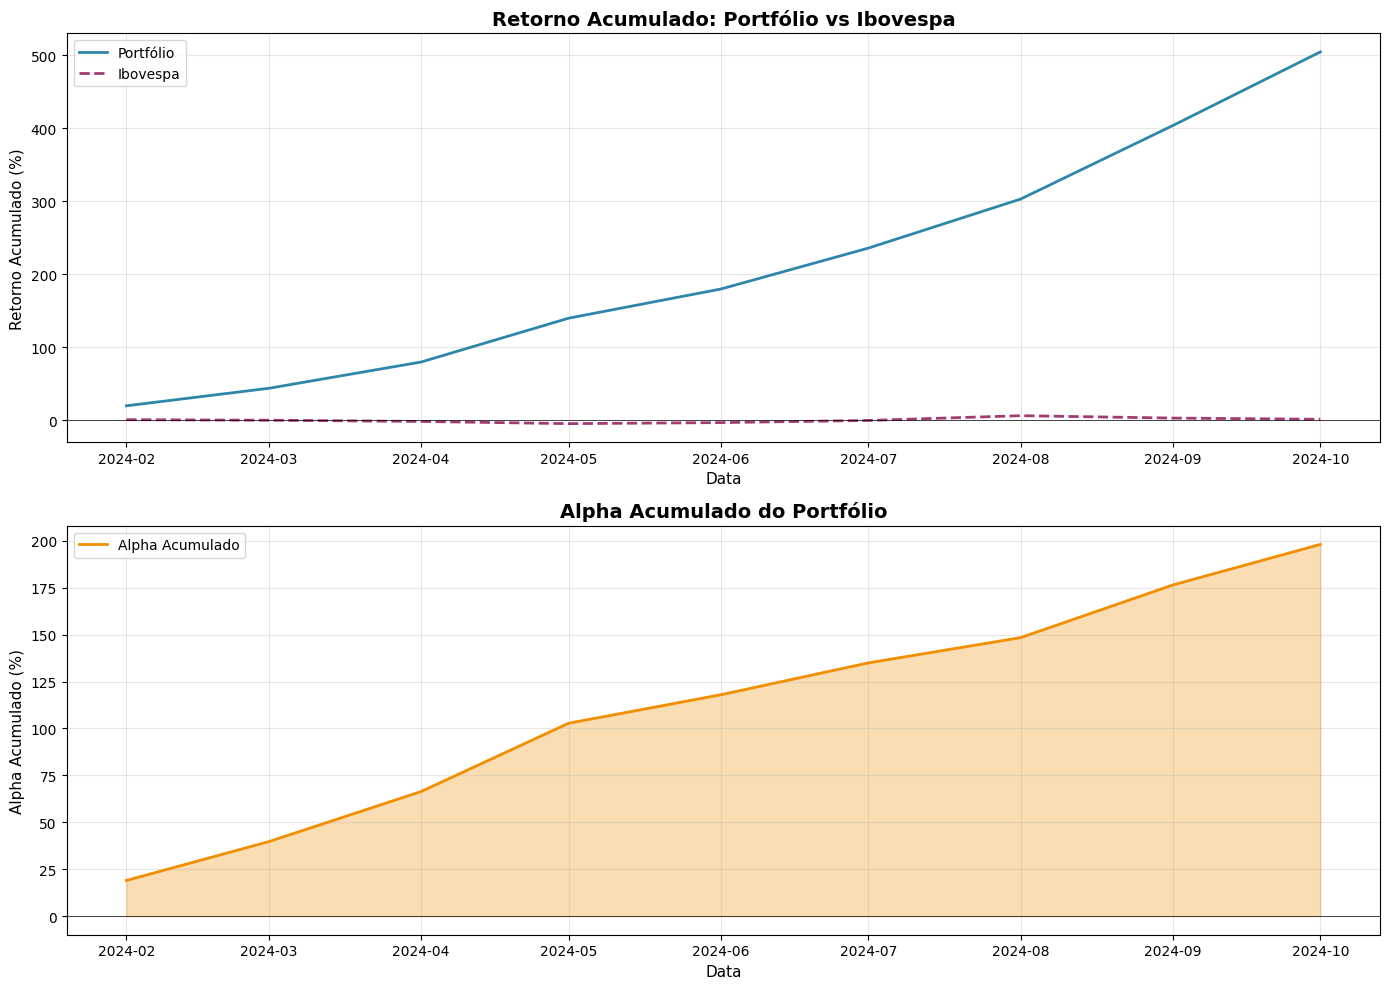


ESTATÍSTICAS DO PORTFÓLIO
Período: 2024-02-01 a 2024-10-01

Retorno Total:
  Portfólio: 504.80%
  Ibovespa:  1.54%

Retorno Médio Mensal:
  Portfólio: 22.22%
  Ibovespa:  0.21%

Volatilidade (Desvio Padrão):
  Portfólio: 4.93%
  Ibovespa:  3.15%

Alpha:
  Alpha Médio Mensal: 22.01%
  Alpha Acumulado:    198.09%

Índice de Sharpe (considerando Ibovespa como risk-free):
  4.4643


In [ ]:
df = pd.read_csv("portfolios_mensais_RF_2024-01-01_2024-12-31.csv")

resultado = analisar_portfolio_vs_ibovespa(df)

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.volume import OnBalanceVolumeIndicator, ChaikinMoneyFlowIndicator
from ta.volatility import AverageTrueRange
from ta.volume import VolumeWeightedAveragePrice
from scipy.optimize import minimize
import warnings
from datetime import datetime
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')

def baixar_e_calcular_indicadores(ticker, start="2010-01-01", end=None):
    """
    Baixa dados e calcula indicadores técnicos.
    """
    try:
        if end is not None:
            data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        else:
            data = yf.download(ticker, start=start, progress=False, auto_adjust=True)
        
        if data.empty:
            return None
        
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
        
        serie = data['Close']
        
        # Indicadores técnicos
        data['SMA_20'] = SMAIndicator(serie, window=20).sma_indicator()
        data['SMA_50'] = SMAIndicator(serie, window=50).sma_indicator()
        data['SMA_200'] = SMAIndicator(serie, window=200).sma_indicator()
        data['EMA_12'] = EMAIndicator(serie, window=12).ema_indicator()
        data['EMA_26'] = EMAIndicator(serie, window=26).ema_indicator()
        data['EMA_50'] = EMAIndicator(serie, window=50).ema_indicator()
        data['RSI_14'] = RSIIndicator(serie, window=14).rsi()
        
        macd = MACD(serie)
        data['MACD'] = macd.macd()
        data['MACD_Hist'] = macd.macd_diff()
        data['ATR_14'] = AverageTrueRange(data['High'], data['Low'], serie, window=14).average_true_range()
        data['ROC_12'] = ROCIndicator(serie, window=12).roc()
        data['OBV'] = OnBalanceVolumeIndicator(serie, data['Volume']).on_balance_volume()
        
        # Retornos e Volatilidade
        data['Ret_1d'] = serie.pct_change(1)
        data['Ret_5d'] = serie.pct_change(5)
        data['Ret_21d'] = serie.pct_change(21)
        data['Vol_21d'] = serie.pct_change().rolling(21).std()
        data['Vol_63d'] = serie.pct_change().rolling(63).std()
        data['Ticker'] = ticker
        
        return data.fillna(method='ffill').dropna()
    except Exception as e:
        print(f"Erro ao baixar {ticker}: {e}")
        return None

def preparar_features_target(df, target_lag=21):
    """
    Prepara features defasadas e target sem vazamento de dados.
    """
    data = df.copy()
    data['Close_Future'] = data['Close'].shift(-target_lag)
    data['Target'] = (data['Close_Future'] - data['Close']) / data['Close']
    
    feature_cols = ['SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'EMA_50',
                    'RSI_14', 'MACD', 'MACD_Hist', 'ATR_14', 'ROC_12', 'OBV',
                    'Ret_1d', 'Ret_5d', 'Ret_21d', 'Vol_21d', 'Vol_63d']
    
    for col in feature_cols:
        data[f'{col}_lag1'] = data[col].shift(1)
    
    data = data.iloc[:-target_lag].copy()
    feature_cols_lag = [col for col in data.columns if col.endswith('_lag1')]
    data = data.dropna(subset=['Target'] + feature_cols_lag).copy()
    
    return data, feature_cols_lag

def treinar_e_prever(df, feature_cols_lag, data_predicao, ticker, modelo_tipo='RF'):
    """
    Treina modelo (RF ou OLS) e faz predição SEM VAZAMENTO DE DADOS.
    Args:
        modelo_tipo: 'RF' para Random Forest ou 'OLS' para Linear Regression
    """
    df_treino = df[df.index <= data_predicao].copy()
    
    if len(df_treino) < 252:
        print(f"  ❌ Dados insuficientes: {len(df_treino)} dias")
        return None
    
    ultima_linha = df_treino.iloc[[-1]]
    features_com_nan = ultima_linha[feature_cols_lag].isna().sum().sum()
    
    if features_com_nan > 0:
        print(f"  ⚠ AVISO: {features_com_nan} features com NaN na última linha")
    
    X_train = df_treino[feature_cols_lag]
    y_train = df_treino['Target']
    
    # Escolher modelo
    if modelo_tipo == 'RF':
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    else:  # OLS
        model = LinearRegression()
    
    model.fit(X_train, y_train)
    
    X_pred = ultima_linha[feature_cols_lag]
    predicao = model.predict(X_pred)[0]
    
    if predicao > 0:
        print(f"\n{'─'*60}")
        print(f"🔍 MODELO: {modelo_tipo} - {ticker}")
        print(f"📊 DADOS DE TREINO:")
        print(f"  • Início: {df_treino.index[0].strftime('%Y-%m-%d')}")
        print(f"  • Fim: {df_treino.index[-1].strftime('%Y-%m-%d')}")
        print(f"  • Total: {len(df_treino)} dias")
        print(f"  • Preço atual: R$ {df_treino['Close'].iloc[-1]:.2f}")
        print(f"  ✅ Predição: {predicao*100:+.2f}%")
    
    return predicao

def calcular_matriz_covariancia(tickers_list, dados_acoes, data_ref, janela=63):
    """
    Calcula matriz de covariância APENAS com dados históricos.
    """
    retornos_hist = []
    print(f"\nDatas da matriz de covariancia")
    
    for ticker in tickers_list:
        df = dados_acoes[ticker]
        df_periodo = df[df.index < data_ref].tail(janela)
        print(f"• {ticker}: {df_periodo.index[0].strftime('%Y-%m-%d')} a {df_periodo.index[-1].strftime('%Y-%m-%d')} ({len(df_periodo)} dias)")
        
        if df_periodo.index[-1] >= data_ref:
            print(f"  🚨 VAZAMENTO: Último dado ({df_periodo.index[-1]}) >= data_ref ({data_ref})")
        
        if len(df_periodo) >= 21:
            retornos = df_periodo['Close'].pct_change().dropna()
            retornos_hist.append(retornos.values)
        else:
            retornos_hist.append(np.zeros(janela-1))
    
    min_len = min(len(r) for r in retornos_hist)
    retornos_df = pd.DataFrame({ticker: r[-min_len:] for ticker, r in zip(tickers_list, retornos_hist)})
    cov_matrix = retornos_df.cov()
    
    return cov_matrix

def otimizar_markowitz(retornos_esperados, cov_matrix, risk_free_rate=0.10/252):
    """
    Otimização de Markowitz: maximizar Sharpe Ratio.
    """
    tickers = list(retornos_esperados.keys())
    n_ativos = len(tickers)
    mu = np.array([retornos_esperados[t] for t in tickers])
    cov = cov_matrix.loc[tickers, tickers].values
    
    def negative_sharpe(weights):
        portfolio_return = np.dot(weights, mu)
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
        sharpe = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else 0
        return -sharpe
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = tuple((0, 0.4) for _ in range(n_ativos))
    w0 = np.array([1/n_ativos] * n_ativos)
    
    result = minimize(
        negative_sharpe,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000}
    )
    
    if result.success:
        pesos = {ticker: peso for ticker, peso in zip(tickers, result.x) if peso > 0.001}
    else:
        pesos = {ticker: 1/n_ativos for ticker in tickers}
    
    return pesos

def calcular_max_drawdown(retornos):
    """Calcula o máximo drawdown."""
    valor_acumulado = (1 + pd.Series(retornos)).cumprod()
    max_anterior = valor_acumulado.cummax()
    drawdown = (valor_acumulado - max_anterior) / max_anterior
    return drawdown.min()

def estrategia_portfolio_mensal(tickers, data_inicio_teste="2024-01-01",
                                data_fim_teste="2024-12-31", n_acoes=8,
                                modelo_tipo='RF', salvar_csv=True):
    """
    Estratégia de portfólio mensal com otimização de Markowitz.
    Args:
        modelo_tipo: 'RF' para Random Forest ou 'OLS' para Regressão Linear
        salvar_csv: Se True, salva portfólios mensais em CSV
    """
    data_inicio_download = pd.to_datetime(data_inicio_teste) - pd.DateOffset(years=5)
    data_fim_download = pd.to_datetime(data_fim_teste) + pd.DateOffset(days=1)
    
    print(f"\n{'='*80}")
    print(f"ESTRATÉGIA DE PORTFÓLIO MENSAL - MODELO: {modelo_tipo}")
    print(f"{'='*80}")
    print(f"Período de teste: {data_inicio_teste} até {data_fim_teste}")
    print(f"Ações no universo: {n_acoes}")
    print(f"Total de tickers: {len(tickers)}")
    print(f"{'='*80}\n")
    
    print(f"📥 Baixando dados históricos...")
    print(f"  • Período: {data_inicio_download.strftime('%Y-%m-%d')} até {data_fim_download.strftime('%Y-%m-%d')}")
    
    dados_acoes = {}
    for ticker in tickers:
        print(f"  → {ticker}", end="... ")
        df = baixar_e_calcular_indicadores(
            ticker,
            start=data_inicio_download.strftime('%Y-%m-%d'),
            end=data_fim_download.strftime('%Y-%m-%d')
        )
        
        if df is not None and len(df) > 252:
            ultima_data = df.index[-1]
            if ultima_data > pd.to_datetime(data_fim_teste):
                df = df[df.index <= pd.to_datetime(data_fim_teste)]
            dados_acoes[ticker] = df
            print(f"✓ ({len(df)} dias, até {df.index[-1].strftime('%Y-%m-%d')})")
        else:
            print("✗ (sem dados suficientes)")
    
    print(f"\n✓ Dados baixados para {len(dados_acoes)} ações")
    
    if len(dados_acoes) < n_acoes:
        n_acoes = len(dados_acoes)
    
    # Preparar features
    dados_preparados = {}
    for ticker, df in dados_acoes.items():
        df_prep, feature_cols = preparar_features_target(df, target_lag=21)
        if len(df_prep) > 0:
            dados_preparados[ticker] = (df_prep, feature_cols)
    
    print(f"✓ Features preparadas para {len(dados_preparados)} ações\n")
    
    # Datas de rebalanceamento
    datas_rebalanceamento = pd.date_range(
        start=data_inicio_teste,
        end=data_fim_teste,
        freq='MS'
    )
    
    print(f"📅 Datas de rebalanceamento: {len(datas_rebalanceamento)} meses\n")
    
    resultados_mensais = []
    portfolios_mensais = []  # Para salvar em CSV
    
    # Para cada mês
    for i, data_rebal_original in enumerate(datas_rebalanceamento, 1):
        print(f"\n{'─'*80}")
        print(f"MÊS {i}: {data_rebal_original.strftime('%B/%Y')}")
        print(f"{'─'*80}")
        
        # CORREÇÃO: Ajustar para próximo dia útil COM DADOS SUFICIENTES
        data_rebal = None
        for offset in range(10):
            data_teste = data_rebal_original + pd.Timedelta(days=offset)
            
            # Verificar se há dados disponíveis para esta data
            tem_dados = any(
                len(df[df.index >= data_teste]) > 0
                for df, _ in dados_preparados.values()
            )
            
            if tem_dados:
                data_rebal = data_teste
                break
        
        if data_rebal is None:
            print(f"⚠ Sem data válida para rebalanceamento")
            continue
        
        if offset > 0:
            print(f"📅 Data ajustada: {data_rebal.strftime('%Y-%m-%d')} (+{offset} dias)")
        
        # CORREÇÃO: Data fim do mês - verificar se há próximo mês
        if i < len(datas_rebalanceamento):
            data_fim_mes = datas_rebalanceamento[i]
        else:
            # Se for último mês, usar a última data disponível nos dados
            ultima_data_disponivel = max([df.index[-1] for df, _ in dados_preparados.values()])
            data_fim_mes = min(pd.to_datetime(data_fim_teste), ultima_data_disponivel)
        
        # Verificar se há dias úteis suficientes após data_rebal
        dias_disponiveis = []
        for df, _ in dados_preparados.values():
            dias_apos = len(df[(df.index > data_rebal) & (df.index <= data_fim_mes)])
            dias_disponiveis.append(dias_apos)
        
        if max(dias_disponiveis) < 2:
            print(f"⚠ Dias insuficientes após {data_rebal.strftime('%Y-%m-%d')} (máx: {max(dias_disponiveis)} dias)")
            continue
        
        # Fazer predições
        predicoes = {}
        for ticker, (df, feature_cols) in dados_preparados.items():
            pred = treinar_e_prever(df, feature_cols, data_rebal, ticker, modelo_tipo)
            if pred is not None:
                predicoes[ticker] = pred
        
        print(f"\n✓ Predições realizadas: {len(predicoes)} ações")
        
        if len(predicoes) < 3:
            print(f"⚠ Poucas predições, pulando")
            continue
        
        # Selecionar top N
        predicoes_sorted = sorted(predicoes.items(), key=lambda x: x[1], reverse=True)
        top_acoes = predicoes_sorted[:min(n_acoes, len(predicoes_sorted))]
        
        print(f"\n📊 TOP {len(top_acoes)} AÇÕES:")
        for rank, (ticker, ret_pred) in enumerate(top_acoes, 1):
            print(f"  {rank}. {ticker:12s} → Retorno previsto: {ret_pred*100:+.2f}%")
        
        # Covariância
        tickers_top = [t for t, _ in top_acoes]
        cov_matrix = calcular_matriz_covariancia(tickers_top, dados_acoes, data_rebal, janela=63)
        
        # Otimizar
        retornos_esperados = {t: r for t, r in top_acoes}
        pesos_otimos = otimizar_markowitz(retornos_esperados, cov_matrix)
        
        print(f"\n🎯 PESOS OTIMIZADOS:")
        for ticker, peso in sorted(pesos_otimos.items(), key=lambda x: x[1], reverse=True):
            print(f"  {ticker:12s} → {peso*100:5.2f}%")
        
        # Salvar portfólio do mês
        portfolio_mes = {
            'Mes': data_rebal_original.strftime('%Y-%m'),
            'Data': data_rebal_original.strftime('%Y-%m-%d'),
            'Modelo': modelo_tipo
        }
        for ticker, peso in pesos_otimos.items():
            portfolio_mes[ticker] = peso
        portfolios_mensais.append(portfolio_mes)
        
        # Calcular retornos reais
        print(f"\n🔍Calculando retornos reais DE {data_rebal.strftime('%Y-%m-%d')} ATÉ {data_fim_mes.strftime('%Y-%m-%d')}")
        retornos_reais = {}
        
        print(f"\n📈 RETORNOS REAIS:")
        for ticker in pesos_otimos.keys():
            df_acao = dados_acoes[ticker]
            df_periodo = df_acao[(df_acao.index > data_rebal) & (df_acao.index <= data_fim_mes)]
            
            if len(df_periodo) >= 2:
                preco_inicio = df_periodo['Close'].iloc[0]
                preco_fim = df_periodo['Close'].iloc[-1]
                retorno_real = (preco_fim - preco_inicio) / preco_inicio
                retornos_reais[ticker] = retorno_real
                
                ret_previsto = retornos_esperados[ticker]
                erro = abs(retorno_real - ret_previsto)
                
                print(f"  {ticker:12s}: Real={retorno_real*100:+6.2f}% | Previsto={ret_previsto*100:+6.2f}% | Erro={erro*100:5.2f}%")
            else:
                retornos_reais[ticker] = 0
        
        # Retorno do portfólio
        retorno_portfolio = sum(retornos_reais.get(t, 0) * peso for t, peso in pesos_otimos.items())
        
        # Benchmark
        ibov = yf.download("^BVSP", start=data_rebal, end=data_fim_mes, progress=False)
        if not ibov.empty and len(ibov) >= 2:
            if isinstance(ibov['Close'], pd.Series):
                preco_ibov_inicio = ibov['Close'].iloc[0]
                preco_ibov_fim = ibov['Close'].iloc[-1]
            else:
                preco_ibov_inicio = ibov['Close'].iloc[0].values[0] if hasattr(ibov['Close'].iloc[0], 'values') else ibov['Close'].iloc[0]
                preco_ibov_fim = ibov['Close'].iloc[-1].values[0] if hasattr(ibov['Close'].iloc[-1], 'values') else ibov['Close'].iloc[-1]
            
            retorno_ibov = (preco_ibov_fim - preco_ibov_inicio) / preco_ibov_inicio
        else:
            retorno_ibov = 0
        
        alpha = retorno_portfolio - retorno_ibov
        
        print(f"\n💰 RESULTADO DO MÊS:")
        print(f"  Retorno do Portfólio: {retorno_portfolio*100:+.2f}%")
        print(f"  Retorno do Ibovespa: {retorno_ibov*100:+.2f}%")
        print(f"  Alpha: {alpha*100:+.2f}%")
        
        portfolio_str = ', '.join([f"{t} ({p*100:.1f}%)" for t, p in sorted(pesos_otimos.items(), key=lambda x: x[1], reverse=True)])
        
        resultados_mensais.append({
            'Mes': data_rebal_original.strftime('%Y-%m'),
            'Data': data_rebal_original,
            'Portfolio': portfolio_str,
            'Retorno_Portfolio': retorno_portfolio,
            'Retorno_Ibov': retorno_ibov,
            'Alpha': alpha
        })
    
    # Salvar portfólios em CSV
    if salvar_csv and len(portfolios_mensais) > 0:
        df_portfolios = pd.DataFrame(portfolios_mensais)
        filename = f'portfolios_mensais_{modelo_tipo}_{data_inicio_teste}_{data_fim_teste}.csv'
        df_portfolios.to_csv(filename, index=False)
        print(f"\n✅ Portfólios salvos em: {filename}")
    
    # Resultados finais
    df_resultados = pd.DataFrame(resultados_mensais)
    
    if len(df_resultados) == 0:
        print("\n⚠ Nenhum resultado para processar")
        return None
    
    retorno_acumulado = (1 + df_resultados['Retorno_Portfolio']).prod() - 1
    retorno_ibov_acumulado = (1 + df_resultados['Retorno_Ibov']).prod() - 1
    volatilidade_portfolio = df_resultados['Retorno_Portfolio'].std() * np.sqrt(12)
    sharpe_ratio = (df_resultados['Retorno_Portfolio'].mean() * 12) / volatilidade_portfolio if volatilidade_portfolio > 0 else 0
    max_drawdown = calcular_max_drawdown(df_resultados['Retorno_Portfolio'].values)
    
    print(f"\n\n{'='*80}")
    print(f"RESULTADO FINAL - MODELO: {modelo_tipo}")
    print(f"{'='*80}")
    print(f"Retorno Acumulado do Portfólio: {retorno_acumulado*100:+.2f}%")
    print(f"Retorno Acumulado do Ibovespa: {retorno_ibov_acumulado*100:+.2f}%")
    print(f"Alpha Total: {(retorno_acumulado-retorno_ibov_acumulado)*100:+.2f}%")
    print(f"\nVolatilidade Anualizada: {volatilidade_portfolio*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Max Drawdown: {max_drawdown*100:.2f}%")
    print(f"\nMeses Positivos: {(df_resultados['Retorno_Portfolio'] > 0).sum()}/{len(df_resultados)}")
    
    # ============================================================================
    # PREVISÃO FORA DA AMOSTRA - MÊS SEGUINTE
    # ============================================================================
    # CORREÇÃO: Usar a última data REALMENTE disponível nos dados
    ultima_data_real = max([df.index[-1] for df, _ in dados_preparados.values()])
    data_limite = min(pd.to_datetime(data_fim_teste), ultima_data_real)
    
    proximo_mes = data_limite + relativedelta(months=1)
    proximo_mes_inicio = proximo_mes.replace(day=1)
    
    print(f"\n{'='*80}")
    print(f"🔮 PREVISÃO FORA DA AMOSTRA - {proximo_mes_inicio.strftime('%B %Y').upper()}")
    print(f"{'='*80}")
    print(f"⚠ ATENÇÃO: Esta previsão usa APENAS dados até {data_limite.strftime('%Y-%m-%d')}")
    print(f"{'='*80}\n")
    
    print(f"📅 Data limite dos dados: {data_limite.strftime('%Y-%m-%d')}")
    print(f"🎯 Fazendo previsão para: {proximo_mes_inicio.strftime('%B %Y')} (próximos 21 dias úteis)")
    
    # Fazer predições para o próximo mês
    predicoes_futuro = {}
    ultimo_dia_treino = {}
    
    print(f"📊 PREDIÇÕES PARA {proximo_mes_inicio.strftime('%B %Y').upper()} (modelo {modelo_tipo}):\n")
    
    for ticker, (df, feature_cols) in dados_preparados.items():
        # CRÍTICO: Usar última data REAL disponível
        df_ate_limite = df[df.index <= data_limite]
        
        if len(df_ate_limite) < 252:
            continue
        
        ultimo_dia = df_ate_limite.index[-1]
        ultimo_dia_treino[ticker] = ultimo_dia
        
        # Treinar modelo
        X_train = df_ate_limite[feature_cols]
        y_train = df_ate_limite['Target']
        
        if modelo_tipo == 'RF':
            model = RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        else:
            model = LinearRegression()
        
        model.fit(X_train, y_train)
        
        X_pred = df_ate_limite[feature_cols].iloc[[-1]]
        predicao = model.predict(X_pred)[0]
        predicoes_futuro[ticker] = predicao
        
        print(f"  {ticker:12s} → Retorno previsto: {predicao*100:+6.2f}% (último treino: {ultimo_dia.strftime('%Y-%m-%d')})")
    
    if len(predicoes_futuro) >= 3:
        # Selecionar top 8
        predicoes_sorted_futuro = sorted(predicoes_futuro.items(), key=lambda x: x[1], reverse=True)
        top_acoes_futuro = predicoes_sorted_futuro[:min(8, len(predicoes_sorted_futuro))]
        
        print(f"\n🏆 TOP 8 AÇÕES RECOMENDADAS PARA {proximo_mes_inicio.strftime('%B %Y').upper()}:")
        for rank, (ticker, ret_pred) in enumerate(top_acoes_futuro, 1):
            ultimo_treino = ultimo_dia_treino[ticker]
            print(f"  {rank}. {ticker:12s} → {ret_pred*100:+6.2f}% (dados até {ultimo_treino.strftime('%Y-%m-%d')})")
        
        # Calcular pesos otimizados
        tickers_top_futuro = [t for t, _ in top_acoes_futuro]
        cov_matrix_futuro = calcular_matriz_covariancia(tickers_top_futuro, dados_acoes, data_limite, janela=63)
        retornos_esperados_futuro = {t: r for t, r in top_acoes_futuro}
        pesos_otimos_futuro = otimizar_markowitz(retornos_esperados_futuro, cov_matrix_futuro)
        
        print(f"\n💼 PORTFÓLIO RECOMENDADO (pesos otimizados):")
        retorno_esperado_portfolio = 0
        for ticker, peso in sorted(pesos_otimos_futuro.items(), key=lambda x: x[1], reverse=True):
            ret_esperado = retornos_esperados_futuro[ticker]
            retorno_esperado_portfolio += peso * ret_esperado
            print(f"  {ticker:12s} → {peso*100:5.2f}% | Retorno esperado: {ret_esperado*100:+6.2f}%")
        
        print(f"\n📈 RETORNO ESPERADO DO PORTFÓLIO: {retorno_esperado_portfolio*100:+.2f}%")


        # Salvar previsão futura em CSV
        if salvar_csv:
            portfolio_futuro = {
                'Mes': proximo_mes_inicio.strftime('%Y-%m'),
                'Data': proximo_mes_inicio.strftime('%Y-%m-%d'),
                'Modelo': modelo_tipo,
                'Retorno_Esperado': retorno_esperado_portfolio
            }
            for ticker, peso in pesos_otimos_futuro.items():
                portfolio_futuro[ticker] = peso
            
            filename_futuro = f'previsao_{proximo_mes_inicio.strftime("%Y-%m")}_{modelo_tipo}.csv'
            pd.DataFrame([portfolio_futuro]).to_csv(filename_futuro, index=False)
            print(f"\n✅ Previsão futura salva em: {filename_futuro}")
    else:
        print(f"\n⚠ Poucas predições disponíveis para {proximo_mes_inicio.strftime('%B %Y')}")